# AIDL – Group Assessment Dataset Loader

**MSc Applied Artificial Intelligence — AI and Deep Learning Module**  
**WMG, University of Warwick — 2025/26**

---

This notebook provides suggested Datasets for the AIDL group assessment.

The goal of this notebook is to ensure that students use the same datasets, avoiding inconsistencies between groups.

The notebook will download and preview the three datasets used in the assessment:

| Dataset | Task |
|------|------|
| **Fashion-MNIST** | Image Classification |
| **Heart Disease (Cleveland)** | Tabular Classification |
| **Amazon Electronics Reviews** | Text Sentiment Analysis |

---

## What you should do

Run each section sequentially to:

1. **Download the dataset you would like to explore**
2. **Load it into Python**
3. **Inspect the data structure**
4. **Verify that it works correctly**

You can then reuse the loading code in your **own model notebooks**.

---

## Environment Requirements

According to the dataset chosen, this notebook might require the following libraries:

- `torch`
- `torchvision`
- `pandas`
- `matplotlib`
- `datasets`
- `numpy`

If you are using **Google Colab**, most libraries are already installed.

If running locally in a `venv`, install them with:

```python
python -m pip install torch torchvision pandas matplotlib datasets

---

# 1. Fashion-MNIST Dataset

Fashion-MNIST is a dataset of **grayscale images of clothing items**.

It is commonly used as a **replacement for MNIST digits** because it is slightly more challenging and more realistic for computer vision tasks.

Each image is:

* **28 × 28 pixels**
* **grayscale**
* labelled with **one of 10 clothing categories**

Running the next cell will **download the dataset automatically the first time**.
After that, it will be loaded from your local cache.

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transformations (Convert to tensor and normalize)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download and load the training data
train_set = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)

# Download and load the test data
test_set = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=False, transform=transform)
test_loader = DataLoader(test_set, batch_size=64, shuffle=True)

print(f"Fashion-MNIST loaded. Training samples: {len(train_set)}, Test samples: {len(test_set)}")

ModuleNotFoundError: No module named 'torch'

### Visualising Sample Images

After loading the dataset, it is always good practice to **inspect the data manually**.

The following cell:

- extracts one batch of images
- selects the first five images
- displays them with their labels

This allows you to verify that:

- the dataset loaded correctly
- the labels correspond to the correct clothing items


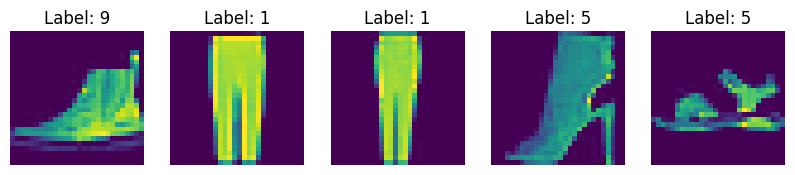

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of training data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Display the first 5 images and their labels
fig, axes = plt.subplots(1, 5, figsize=(10, 5))
for i in range(5):
    # Unnormalize the image for display
    img = images[i] / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    axes[i].imshow(np.transpose(npimg, (1, 2, 0)))
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis('off')
plt.show()

# 2. Heart Disease Dataset

This dataset contains **clinical measurements used to predict the presence of heart disease**.

The version used in machine learning research is the **Cleveland Heart Disease dataset**, which is part of the larger UCI Heart Disease database.

Although the full database contains **76 attributes**, most studies use **a subset of 14 key attributes**, which we will also use in this module.

These attributes include:

- demographic data
- clinical test results
- exercise measurements
- cardiovascular indicators

The target variable indicates **whether the patient has heart disease**.

Values range from:

- **0 → no disease**
- **1–4 → presence of disease**

For machine learning experiments, this is usually simplified to:

- **0 → No Heart Disease**
- **1 → Heart Disease Present**

---

## What the next cell does

The following code will:

1. Download the dataset from a public repository
2. Load it using **Pandas**
3. Display the first few rows
4. Allow you to inspect the features

In [ ]:
import pandas as pd

# Direct link to the raw data
url = "https://raw.githubusercontent.com/dataprofessor/data/master/heart-disease-cleveland.csv"

df = pd.read_csv(url)

# Display the first 5 rows
print("Heart Disease Dataset Preview:")
print(df.head())

Heart Disease Dataset Preview:
   age   sex   cp   trestbps   chol   fbs   restecg   thalach   exang  \
0   63     1    1        145    233     1         2       150       0   
1   67     1    4        160    286     0         2       108       1   
2   67     1    4        120    229     0         2       129       1   
3   37     1    3        130    250     0         0       187       0   
4   41     0    2        130    204     0         2       172       0   

    oldpeak   slope   ca  thal   diagnosis  
0       2.3       3  0.0   6.0           0  
1       1.5       2  3.0   3.0           2  
2       2.6       2  2.0   7.0           1  
3       3.5       3  0.0   3.0           0  
4       1.4       1  0.0   3.0           0  


# 3. Amazon Electronics Reviews Dataset

This dataset contains **customer reviews from Amazon Electronics products**.

Each record includes:

- the review text
- the rating given by the user
- product identifiers
- metadata about the review

Because the full dataset contains **millions of reviews**, we will **stream the dataset and sample a subset**.

This allows us to:

- avoid downloading massive files
- work with a manageable dataset
- run experiments efficiently

---

## What the next cell does

The code below will:

1. Stream the Amazon Electronics dataset
2. Extract **50,000 reviews**
3. Convert the data to a **Pandas DataFrame**
4. Allow you to inspect the columns and structure

In [ ]:
import itertools
from datasets import load_dataset, Dataset

REVIEWS_URL = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Electronics.jsonl"
ds_iter = load_dataset("json", data_files=REVIEWS_URL, split="train", streaming=True)

# Loading a subset of 50,000 English reviews for the assessment
sample = list(itertools.islice(ds_iter, 50000))  # Adjust sample size as needed
dataset = Dataset.from_list(sample)

# Convert to dataset to pandas Dataframe
df = dataset.to_pandas()
print(f"Working dataset size: {len(df):,} reviews")

Working dataset size: 50,000 reviews


In [ ]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,True
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,1290278495000,18,True
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1676601581238,0,True


---

# Data Dictionaries

---

# 1. Fashion-MNIST Data Dictionary

Fashion-MNIST contains **70,000 grayscale images of clothing items**.

| Attribute | Description               |
| --------- | ------------------------- |
| image     | 28 × 28 grayscale image   |
| label     | Integer class label (0–9) |

### Dataset Structure

| Split    | Images |
| -------- | ------ |
| Training | 60,000 |
| Test     | 10,000 |

### Image Properties

| Property    | Value         |
| ----------- | ------------- |
| Image size  | 28 × 28       |
| Channels    | 1 (grayscale) |
| Pixel range | 0–255         |

### Class Labels

| Label | Class         |
| ----- | ------------- |
| 0     | T-shirt / Top |
| 1     | Trouser       |
| 2     | Pullover      |
| 3     | Dress         |
| 4     | Coat          |
| 5     | Sandal        |
| 6     | Shirt         |
| 7     | Sneaker       |
| 8     | Bag           |
| 9     | Ankle Boot    |

---

# 2. Heart Disease Dataset Data Dictionary

The Cleveland Heart Disease dataset contains **clinical measurements used to diagnose coronary artery disease**.

Only **14 attributes** are typically used in machine learning experiments.

| Feature  | Description                                           |
| -------- | ----------------------------------------------------- |
| age      | Age of the patient (years)                            |
| sex      | Sex (1 = male, 0 = female)                            |
| cp       | Chest pain type                                       |
| trestbps | Resting blood pressure (mm Hg)                        |
| chol     | Serum cholesterol (mg/dl)                             |
| fbs      | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) |
| restecg  | Resting electrocardiographic results                  |
| thalach  | Maximum heart rate achieved                           |
| exang    | Exercise induced angina (1 = yes, 0 = no)             |
| oldpeak  | ST depression induced by exercise relative to rest    |
| slope    | Slope of peak exercise ST segment                     |
| ca       | Number of major vessels colored by fluoroscopy        |
| thal     | Thalassemia test result                               |
| num      | Diagnosis of heart disease (target variable)          |

---

### Chest Pain Type (cp)

| Value | Meaning          |
| ----- | ---------------- |
| 1     | Typical angina   |
| 2     | Atypical angina  |
| 3     | Non-anginal pain |
| 4     | Asymptomatic     |

---

### Resting ECG (restecg)

| Value | Meaning                      |
| ----- | ---------------------------- |
| 0     | Normal                       |
| 1     | ST-T wave abnormality        |
| 2     | Left ventricular hypertrophy |

---

### Slope of ST Segment (slope)

| Value | Meaning     |
| ----- | ----------- |
| 1     | Upsloping   |
| 2     | Flat        |
| 3     | Downsloping |

---

### Thalassemia (thal)

| Value | Meaning           |
| ----- | ----------------- |
| 3     | Normal            |
| 6     | Fixed defect      |
| 7     | Reversible defect |

---

### Target Variable (num)

| Value | Meaning                   |
| ----- | ------------------------- |
| 0     | No heart disease          |
| 1–4   | Presence of heart disease |

In most ML tasks:

```
0 = No disease
1 = Disease present
```

---

# 3. Amazon Electronics Reviews Dataset Data Dictionary

This dataset contains **customer reviews of electronics products on Amazon**.

Each row corresponds to **one review**.

| Feature           | Description                       |
| ----------------- | --------------------------------- |
| images            | List of URLs posted with the review          |
| user_id           | Anonymous Reviewer Identifier     |
| asin              | Amazon Standard Product identifier number    |
| parent_asin       | Parent product ID (group variants)           |
| rating            | Star rating (1–5)                 |
| title             | Review title/customer headline    |
| text              | Full customer review text         |
| timestamp         | Time when the review was posted (miliseconds)|
| verified_purchase | Whether the purchase was verified |
| helpful_vote      | Number of helpful votes received  |

---

### Rating Interpretation

| Rating | Meaning         |
| ------ | --------------- |
| 1–2    | Negative review |
| 3      | Neutral review  |
| 4–5    | Positive review |

In many sentiment analysis tasks this is simplified to:

```
1–2 → Negative
4–5 → Positive
```

---